In [38]:
from dace_query.sun import Sun
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np
import jdcal as j 
from astropy.time import Time
from pathlib import Path

import pandas as pd


In [39]:
# data_original = Sun.query_database(output_format="pandas")

# sorted(data_original.columns.to_list())

In [40]:
# # Remove some outliers that are more than 25 m/s away from the median
# to_keep = (
#     np.abs(data_original.spectro_ccf_rv - np.median(data_original.spectro_ccf_rv)) < 25
# )
# data = data_original[to_keep]

In [41]:
# # Plot the raw radial velocities, in the Solar System barycenter rest frame
# plt.figure(figsize=(10, 5))
# plt.plot(data.obj_date_bjd, data.spectro_ccf_rv, ".")
# plt.xlabel("BJD - 2400000 [d] [m/s]")
# plt.ylabel("RV [m/s]")
# plt.tight_layout()

In [42]:
# plt.plot(
#     data.obj_date_bjd,
#     data.spectro_ccf_rv_corr,
#     marker=".",
#     ls="",
#     ms=5,
#     color="C3",
#     label="data.rv",
# )
# plt.legend()
# plt.xlabel("BJD - 2400000 [d] [m/s]")
# plt.ylabel("RV [m/s]")
# # plt.ylim(50,150)
# # plt.xlim(57400, 57500)
# plt.tight_layout()

In [43]:
data = pd.read_csv('/home/sophie-stucki/Downloads/2015-2025/2015-2025/harpn_sun_release_timeseries_2015-2025.csv')


In [44]:
date = Time(np.array(data.bjd), format='jd', scale='tdb')
arg_sort = date.argsort()

rv = np.array(data.rv)[arg_sort] * 1e3
fwhm = np.array(data.fwhm)[arg_sort] * 1e3

# bis = np.array(data.spectro_ccf_bispan)[arg_sort]
# fwhm = np.array(data.spectro_ccf_fwhm_corr)[arg_sort]
# contrast = np.array(data.spectro_ccf_contrast)[arg_sort]

date = date[arg_sort]

In [45]:
t = Time(data.bjd + 2400000, format='jd', scale='tdb')

# Convert to UTC calendar date
t_utc = t.utc

print("UTC date:", t_utc.iso)

UTC date: ['2015-07-16 10:44:16.880' '2015-07-16 10:49:40.319'
 '2015-07-16 10:55:04.201' ... '2025-05-08 14:24:26.482'
 '2025-05-08 14:35:13.894' '2025-05-08 14:40:37.884']


In [46]:
start_time = j.gcal2jd(2017,7,1)[1] + 2400000.5
end_time = j.gcal2jd(2017,9,1)[1] + 2400000.5

date_harps = []
date_harps_fits = []

rv_harps = []
bis_harps = []
fwhm_harps = []
contrast_harps = []

for i in range(len(date)):
    if t_utc.jd[i] >= start_time and t_utc.jd[i] <= end_time:

        date_harps.append(t_utc[i])
        date_harps_fits.append(t_utc[i].to_value('iso', 'date'))

        rv_harps.append(rv[i])
        # bis_harps.append(bis[i])
        fwhm_harps.append(fwhm[i])
        # contrast_harps.append(contrast[i])

print(date_harps_fits)

['2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-01', '2017-07-02', '2017-07-02', '2017-07-02', '2017-07-02', '2017-07-02', '2017-07-02', '2017-07-02', '2017-07-02', '2017

In [47]:
data_test = pd.DataFrame({'date': date_harps_fits,
             'rv': rv_harps,
             'fwhm': fwhm_harps})
            #  'contrast': contrast_harps})

# daily_avg = data_test.groupby('date')[['rv', 'bis', 'fwhm', 'contrast']].mean().reset_index()
daily_avg = data_test.groupby('date')[['rv', 'fwhm']].mean().reset_index()


start_time = Time(start_time, format='jd')

days_harps = [(day - start_time).value for day in date_harps]
days_daily_avg = [(Time(str(day) + ' 00:00:00.000', format='iso') - start_time).value + 0.5 for day in daily_avg.date]


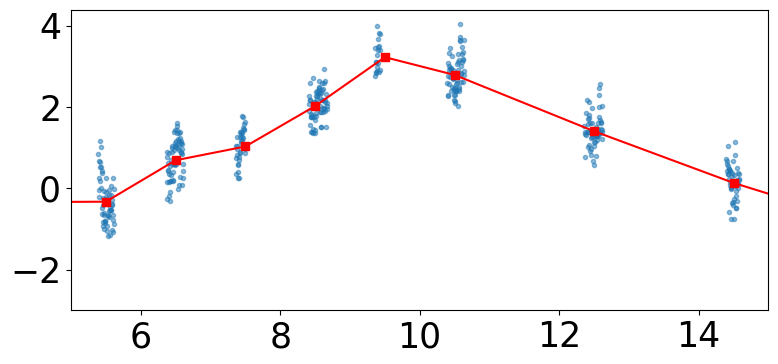

In [48]:
plt.plot(days_harps, rv_harps - np.mean(rv_harps), '.', alpha=0.5)
plt.plot(days_daily_avg, daily_avg.rv - np.mean(daily_avg.rv), 'sr-')
plt.xlim(5,15)
plt.show()

# plt.plot(daily_avg.date, daily_avg.bis - np.mean(daily_avg.bis), 'r')
# plt.plot(date_harps, bis_harps - np.mean(bis_harps), '.')

# plt.show()

# plt.plot(daily_avg.date, daily_avg.fwhm - np.mean(daily_avg.fwhm), 'r')
# plt.plot(date_harps, fwhm_harps - np.mean(fwhm_harps), '.')

# plt.show()

# plt.plot(daily_avg.date, daily_avg.contrast - np.mean(daily_avg.contrast), 'r')
# plt.plot(date_harps, contrast_harps - np.mean(contrast_harps), '.')

# plt.show()

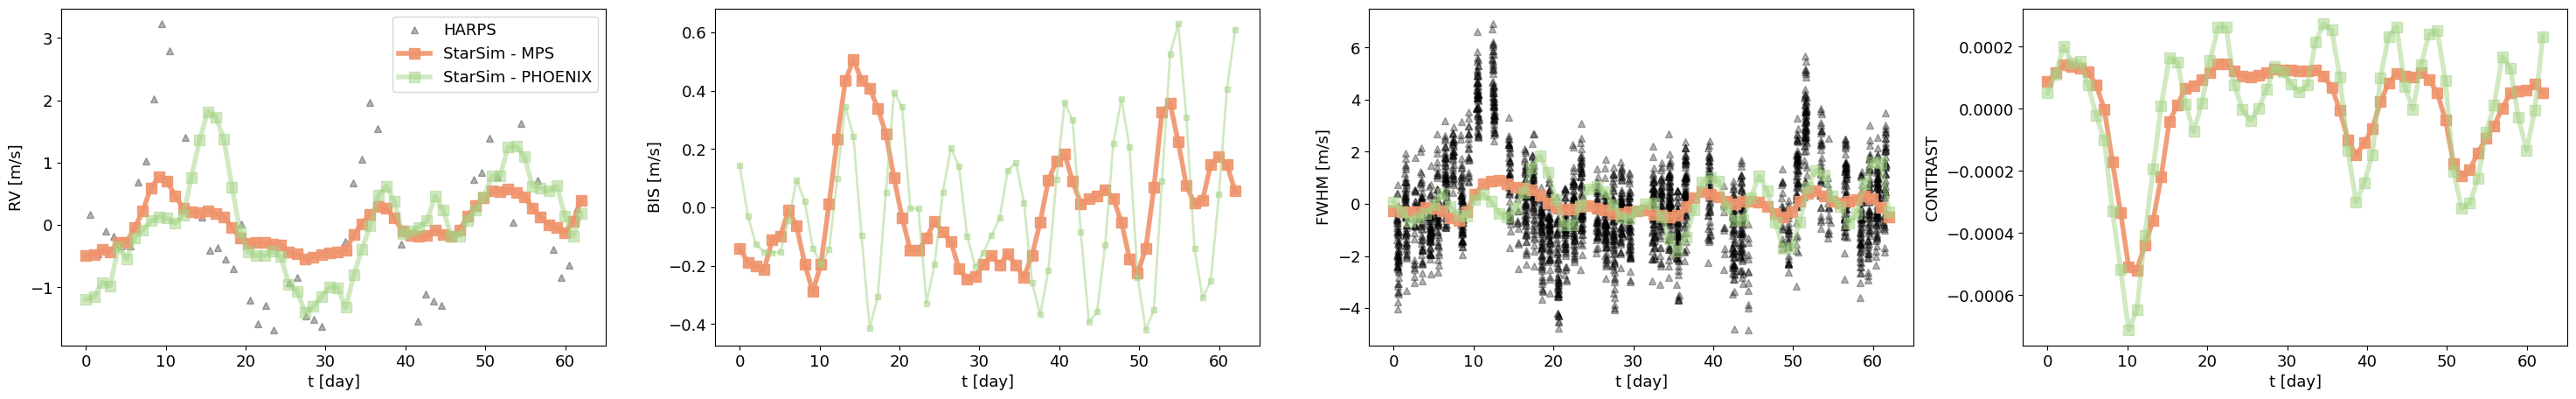

In [49]:
rv_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/rv_test_mps.txt')
rv_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/rv_test_phoenix.txt')

bis_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/bis_test_mps.txt')
bis_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/bis_test_phoenix.txt')

fwhm_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/fwhm_test_mps.txt')
fwhm_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/fwhm_test_phoenix.txt')

cont_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/cont_test_mps.txt')
cont_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/cont_test_phoenix.txt')

racoon_rv = pd.read_csv('/home/sophie-stucki/Documents/starsim_simulations/harps/rv.csv')
racoon_mps_rv = pd.read_csv('/home/sophie-stucki/Documents/starsim_simulations/harps/rv_mps_racoon.csv')


days_simu = np.linspace(0, 62, 62)


plt.rcParams['font.size'] = 13


fig, axs = plt.subplots(1,4, figsize=(37,5))

axs[0].plot( days_daily_avg,  daily_avg.rv - np.mean(daily_avg.rv),'^', label='HARPS', color="#000000", alpha =0.3)
axs[0].plot(days_simu, rv_simu_mps - np.mean(rv_simu_mps) ,'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=8, linewidth=4)
axs[0].plot(days_simu, rv_simu_phoenix - np.mean(rv_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=8, linewidth=4)
axs[0].set_xlabel('t [day]')
axs[0].set_ylabel('RV [m/s]')

# axs[1].plot( days_harps,  bis_harps - np.mean(bis_harps),'^', label='HARPS', color="#000000", alpha =0.3)
axs[1].plot(days_simu, bis_simu_mps - np.mean(bis_simu_mps) ,'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=8, linewidth=4)
axs[1].plot(days_simu, bis_simu_phoenix - np.mean(bis_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=4, linewidth=2)
axs[1].set_xlabel('t [day]')
axs[1].set_ylabel('BIS [m/s]')

axs[2].plot( days_harps,  fwhm_harps - np.mean(fwhm_harps),'^', label='HARPS', color="#000000", alpha =0.3)
axs[2].plot(days_simu, fwhm_simu_mps - np.mean(fwhm_simu_mps) ,'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=8, linewidth=4)
axs[2].plot(days_simu, fwhm_simu_phoenix - np.mean(fwhm_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5,markersize=8, linewidth=4)
axs[2].set_xlabel('t [day]')
axs[2].set_ylabel('FWHM [m/s]')

# axs[3].plot( days_harps,  contrast_harps - np.mean(contrast_harps),'^', label='HARPS', color="#000000", alpha =0.3)
axs[3].plot(days_simu, cont_simu_mps - np.mean(cont_simu_mps) ,'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=8, linewidth=4)
axs[3].plot(days_simu, cont_simu_phoenix - np.mean(cont_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=8, linewidth=4)
axs[3].set_xlabel('t [day]')
axs[3].set_ylabel('CONTRAST')

axs[0].legend()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_spec.png',  dpi=300, bbox_inches='tight')
# plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_spec_mean.png',  dpi=300, bbox_inches='tight')


plt.show()

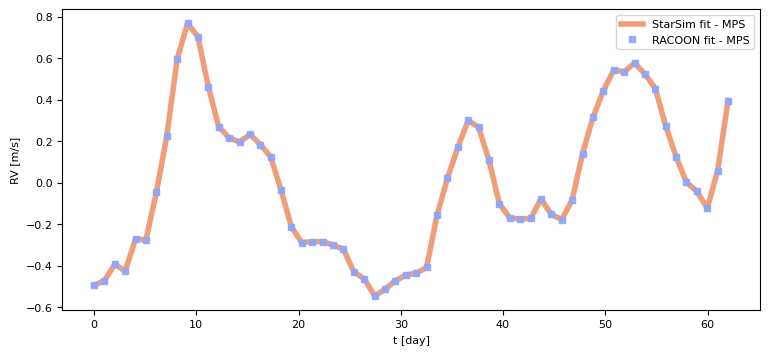

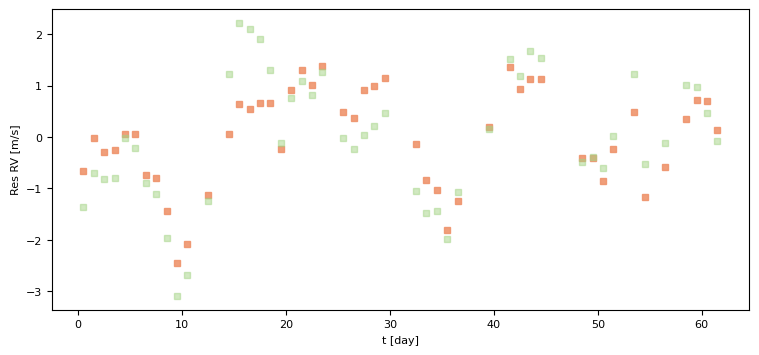

In [50]:
plt.rcParams['font.size'] = 8

masks= np.isnan(racoon_rv.rv)

# plt.plot( racoon_rv.days[~masks],  1e3 * (racoon_rv.rv[~masks] - np.mean(racoon_rv.rv[~masks])),'^-', label='HARPS-N- RACOON', color="#A764DA", alpha =0.4)

# plt.plot( days_daily_avg,  daily_avg.rv - np.mean(daily_avg.rv),'^--', label='HARPS-N', color="#000000", alpha =0.3)
plt.plot(days_simu, rv_simu_mps - np.mean(rv_simu_mps) ,'-', label = 'StarSim fit - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=4)
plt.plot(days_simu , racoon_mps_rv.rv - np.mean(racoon_mps_rv.rv) ,'s', label = 'RACOON fit - MPS', color="#8ba6ff", alpha=0.9, markersize=5, linewidth=4)

# plt.plot(days_simu, rv_simu_phoenix - np.mean(rv_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=5, linewidth=4)
plt.xlabel('t [day]')
plt.ylabel('RV [m/s]')
plt.legend()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_rv.png',  dpi=300, bbox_inches='tight')

plt.show()

for i, t in enumerate(days_daily_avg):
    plt.plot(t, rv_simu_mps[int(t)] - np.mean(rv_simu_mps) - (daily_avg.rv[i] - np.mean(daily_avg.rv)),'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=4)
    plt.plot(t, rv_simu_phoenix[int(t)] - np.mean(rv_simu_phoenix) - (daily_avg.rv[i] - np.mean(daily_avg.rv)),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=5, linewidth=4)
plt.xlabel('t [day]')
plt.ylabel('Res RV [m/s]')
# plt.legend()
plt.show()

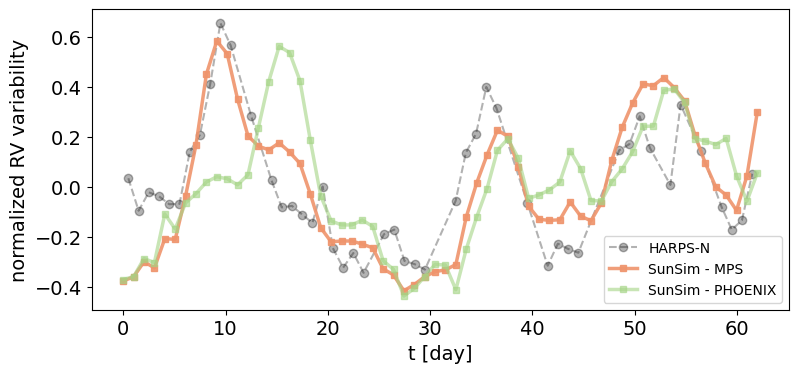

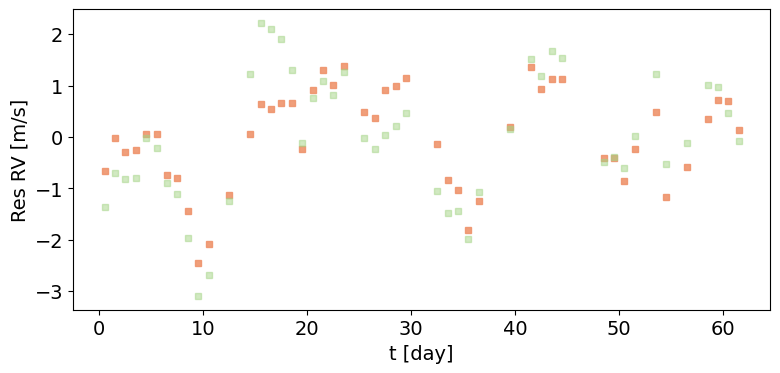

In [51]:
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (9,3.9)
# plt.plot( racoon_rv.days[~masks], (racoon_rv.rv[~masks] - np.mean(racoon_rv.rv[~masks])) / np.max((racoon_rv.rv[~masks] - np.mean(racoon_rv.rv[~masks]))),'^-', label='HARPS-N- RACOON', color="#A764DA", alpha =0.4)

plt.plot( days_daily_avg,  (daily_avg.rv - np.mean(daily_avg.rv)) / (np.max( daily_avg.rv - np.mean(daily_avg.rv)) - np.min( daily_avg.rv - np.mean(daily_avg.rv))),'o--', label='HARPS-N', color="#000000", alpha =0.3)
plt.plot(days_simu, (rv_simu_mps - np.mean(rv_simu_mps)) / (np.max(rv_simu_mps - np.mean(rv_simu_mps))- np.min(rv_simu_mps - np.mean(rv_simu_mps))) ,'s-', label = 'SunSim - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=2.5)
plt.plot(days_simu, (rv_simu_phoenix - np.mean(rv_simu_phoenix)) / (np.max(rv_simu_phoenix - np.mean(rv_simu_phoenix))- np.min(rv_simu_phoenix - np.mean(rv_simu_phoenix))),'s-', label = 'SunSim - PHOENIX', color="#a4d485", alpha=0.6, markersize=5, linewidth=2.5)
plt.xlabel('t [day]')
plt.ylabel('normalized RV variability')
plt.legend(fontsize=10)
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_rv_shape.png',  dpi=300, bbox_inches='tight')

plt.show()

for i, t in enumerate(days_daily_avg):
    plt.plot(t, rv_simu_mps[int(t)] - np.mean(rv_simu_mps) - (daily_avg.rv[i] - np.mean(daily_avg.rv)),'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=4)
    plt.plot(t, rv_simu_phoenix[int(t)] - np.mean(rv_simu_phoenix) - (daily_avg.rv[i] - np.mean(daily_avg.rv)),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=5, linewidth=4)
plt.xlabel('t [day]')
plt.ylabel('Res RV [m/s]')
# plt.legend()
plt.show()

In [52]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 25

def match_yaxis_range_and_ticks(ax1, ax2, data1, data2, num_ticks=5):
    min1, max1 = np.min(data1), np.max(data1)
    min2, max2 = np.min(data2), np.max(data2)

    span1 = max1 - min1
    span2 = max2 - min2
    full_span = max(span1, span2)

    pad = 0.05 * full_span
    full_span += 2 * pad

    center1 = (max1 + min1) / 2
    center2 = (max2 + min2) / 2

    ax1.set_ylim(center1 - full_span / 2, center1 + full_span / 2)
    ax2.set_ylim(center2 - full_span / 2, center2 + full_span / 2)

    ticks1 = np.linspace(center1 - full_span / 2, center1 + full_span / 2, num_ticks)
    ticks2 = np.linspace(center2 - full_span / 2, center2 + full_span / 2, num_ticks)

    ax1.set_yticks(ticks1)
    ax2.set_yticks(ticks2)


# === Load your data here ===
# Replace the following lines with your actual data variables:
# Example placeholders:
# days_simu = np.array([...])
# rv_simu_mps = np.array([...])
# rv_simu_phoenix = np.array([...])
# bis_simu_mps = np.array([...])
# bis_simu_phoenix = np.array([...])
# fwhm_simu_mps = np.array([...])
# fwhm_simu_phoenix = np.array([...])
# cont_simu_mps = np.array([...])
# cont_simu_phoenix = np.array([...])

# -------------------
# RV plot
fig, ax0 = plt.subplots(figsize=(8, 5))
ax0b = ax0

# ax0.plot(days_simu, rv_simu_mps, 's-', label='StarSim - MPS', color='#ef946c', alpha=0.9, markersize=4, linewidth=2)
ax0b.plot(days_simu, rv_simu_phoenix, 's-', label='SunSim: PHOENIX', color='#a4d485', alpha=1, markersize=4, linewidth=2)

ax0.set_xlabel('t [day]')
ax0.set_ylabel('RV [m/s]')
# ax0b.spines['right'].set_position(('axes', 1))
# ax0b.tick_params(axis='y', labelcolor='#a4d485')
# ax0.tick_params(axis='y', labelcolor='#ef946c')

# match_yaxis_range_and_ticks(ax0, ax0b, rv_simu_mps, rv_simu_phoenix)

lines1, labels1 = ax0.get_legend_handles_labels()
lines2, labels2 = ax0b.get_legend_handles_labels()
# ax0.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax0.legend(fontsize=20)

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_spec_RV.png', dpi=300, bbox_inches='tight', transparent=True)
plt.close()


# -------------------
# BIS plot
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1b = ax1.twinx()

ax1.plot(days_simu, bis_simu_mps , 's-', label='StarSim - MPS', color='#ef946c', alpha=0.9, markersize=4, linewidth=2)
ax1b.plot(days_simu, bis_simu_phoenix , 's-', label='StarSim - PHOENIX', color='#a4d485', alpha=0.5, markersize=4, linewidth=2)

ax1.set_xlabel('t [day]')
ax1.set_ylabel('BIS [m/s]')
ax1b.spines['right'].set_position(('axes', 1))
ax1b.tick_params(axis='y', labelcolor='#a4d485')
ax1.tick_params(axis='y', labelcolor='#ef946c')

match_yaxis_range_and_ticks(ax1, ax1b, bis_simu_mps, bis_simu_phoenix)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_spec_BIS.png', dpi=300, bbox_inches='tight', transparent=True)
plt.close()


# -------------------
# FWHM plot
fig, ax2 = plt.subplots(figsize=(8, 5))
ax2b = ax2.twinx()

ax2.plot(days_simu, fwhm_simu_mps, 's-', label='StarSim - MPS', color='#ef946c', alpha=0.9, markersize=4, linewidth=2)
ax2b.plot(days_simu, fwhm_simu_phoenix, 's-', label='StarSim - PHOENIX', color='#a4d485', alpha=0.5, markersize=4, linewidth=2)

ax2.set_xlabel('t [day]')
ax2.set_ylabel('FWHM [m/s]')
ax2b.spines['right'].set_position(('axes', 1))
ax2b.tick_params(axis='y', labelcolor='#a4d485')
ax2.tick_params(axis='y', labelcolor='#ef946c')

match_yaxis_range_and_ticks(ax2, ax2b, fwhm_simu_mps, fwhm_simu_phoenix)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
# ax2.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_spec_FWHM.png', dpi=300, bbox_inches='tight', transparent=True)
plt.close()


# -------------------
# CONTRAST plot
fig, ax3 = plt.subplots(figsize=(8, 5))
ax3b = ax3.twinx()

ax3.plot(days_simu, cont_simu_mps, 's-', label='StarSim - MPS', color='#ef946c', markersize=4, linewidth=2)
ax3b.plot(days_simu, cont_simu_phoenix, 's-', label='StarSim - PHOENIX', color='#a4d485', markersize=4, linewidth=2)

ax3.set_xlabel('t [day]')
ax3.set_ylabel('CONTRAST')
ax3b.spines['right'].set_position(('axes', 1))
ax3b.tick_params(axis='y', labelcolor='#a4d485')
ax3.tick_params(axis='y', labelcolor='#ef946c')

match_yaxis_range_and_ticks(ax3, ax3b, cont_simu_mps, cont_simu_phoenix)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_spec_CONTRAST.png', dpi=300, bbox_inches='tight', transparent=True)
plt.close()


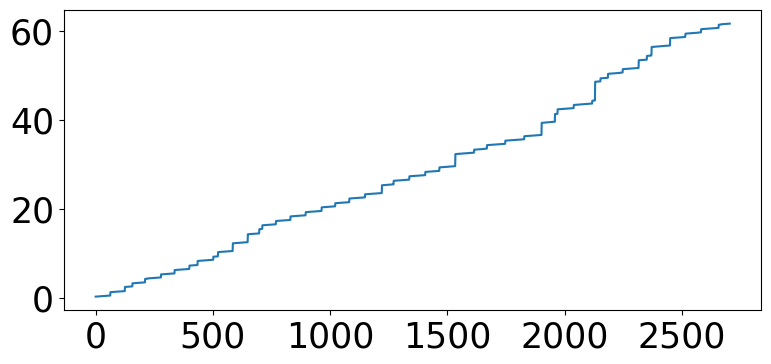

In [53]:
plt.plot(np.sort(days_harps))

In [54]:
map_satire = np.load('/home/sophie-stucki/starsim/starsim/SDO_input/spots_satire.npy', allow_pickle=True).item()

In [55]:
umbra = []
penumbra = []
for i in range(62):
    date = str((start_time + i).fits).replace('-', '.').replace('T0', '_0').replace('.000', '')
    umbra.append(map_satire['/scratch/HF/masks/{}_TAI_bmu_mask.sav'.format(date)]['umbra'])
    penumbra.append(map_satire['/scratch/HF/masks/{}_TAI_bmu_mask.sav'.format(date)]['penumbra'])


KeyError: '/scratch/HF/masks/2017.07.05_00:00:00_TAI_bmu_mask.sav'

In [ ]:
map_satire

{'/scratch/HF/masks/2010.05.01_01:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(42),
  'penumbra': np.int64(268)},
 '/scratch/HF/masks/2010.05.02_00:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(0),
  'penumbra': np.int64(200)},
 '/scratch/HF/masks/2010.05.03_01:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(97),
  'penumbra': np.int64(501)},
 '/scratch/HF/masks/2010.05.04_01:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(53),
  'penumbra': np.int64(599)},
 '/scratch/HF/masks/2010.05.05_00:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(269),
  'penumbra': np.int64(1048)},
 '/scratch/HF/masks/2010.05.06_00:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(168),
  'penumbra': np.int64(1260)},
 '/scratch/HF/masks/2010.05.07_00:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(33),
  'penumbra': np.int64(429)},
 '/scratch/HF/masks/2010.05.08_00:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(21),
  'penumbra': np.int64(207)},
 '/scratch/HF/masks/2010.05.09_00:00:00_TAI_bmu_mask.sav': {'umbra': np.int64(0),
  'penumbra

In [ ]:
/scratch/HF/masks/2017.07.01_00:00:00.000_TAI_bmu_mask.sav
/scratch/HF/masks/2017.07.01_00:00:00_TAI_bmu_mask.sav

2017